# Parametric sweep: ARC_V0 triangularity scan

`fusdb.run_many` solves one reactor across a set of parametric **cases** in
parallel -- the pointwise-faithful generalisation of the 2-D popcon grid to
arbitrary input variations.  Each case pins some variables to fixed values and
runs a full, independent solve (here `reconcile`) around them.

This notebook scans the plasma **triangularity** `delta` of ARC_V0 from -0.7 to
0.7 (16 points) and looks at how the reconciled operating point responds.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fusdb import run_many

project_root = Path.cwd().resolve()
if not (project_root / "reactors").is_dir():
    project_root = project_root.parent
ARC = project_root / "reactors" / "ARC_V0" / "reactor.yaml"


## Build the cases and run the sweep

One case per triangularity value: `{"delta": d}`.  `delta` is pinned as a fixed
input, so each reconcile holds that triangularity exactly and solves the rest of
the machine around it.

The scan uses two worker processes so it remains practical in a notebook.
Increase `NUM` or `workers` when exploring on a larger machine.


In [2]:
NUM = 16
deltas = np.linspace(-0.7, 0.7, NUM)
cases = [{"delta": float(d)} for d in deltas]

columns = run_many(ARC, cases, mode="reconcile", workers=2)   # list[SolvedColumn], one per case, in order
print(f"ran {len(columns)} cases")


ran 16 cases


## Extract the reconciled quantities

Each returned `SolvedColumn` carries `.values` (solved variables, SI units) and
`.result` (the full mode result: `success`, `diagnostics`, `inputs_beyond_tolerance`, ...).
`P_fus` is in watts, so divide by 1e6 for MW.


In [3]:
def col(name, scale=1.0):
    return np.array([c.values.get(name, np.nan) if c.values.get(name) is not None else np.nan
                     for c in columns], dtype=float) * scale

P_fus = col("P_fus", 1e-6)     # MW
V_p   = col("V_p")             # m^3
Q     = col("Q")               # fusion gain
f_GW  = col("f_GW")            # Greenwald fraction
success = np.array([bool(c.result.get("success")) for c in columns])
print(f"reconciled (verified) at {success.sum()}/{len(columns)} points")


reconciled (verified) at 16/16 points


## How the operating point responds to triangularity

**Caveat, measured below:** the scan certifies at (nearly) every point, but on a
richly-specified scenario like ARC_V0 that does **not** mean these three curves
are functions of `delta`. `f_GW` is a fixed input and does not move at all, and `P_fus`
is supplied-with-tolerance and sits at its supplied value at most points; `V_p`
moves ~44% but non-monotonically, with step-to-step jitter far larger than its
trend across the axis -- that is the solver picking
between nearby roots, not triangularity physics. The quantities that genuinely
respond to `delta` here are `f_shaping` and the plasma surface area `A_p`. The
diagnostic cell after the plots quantifies this; read it before reading the plots.


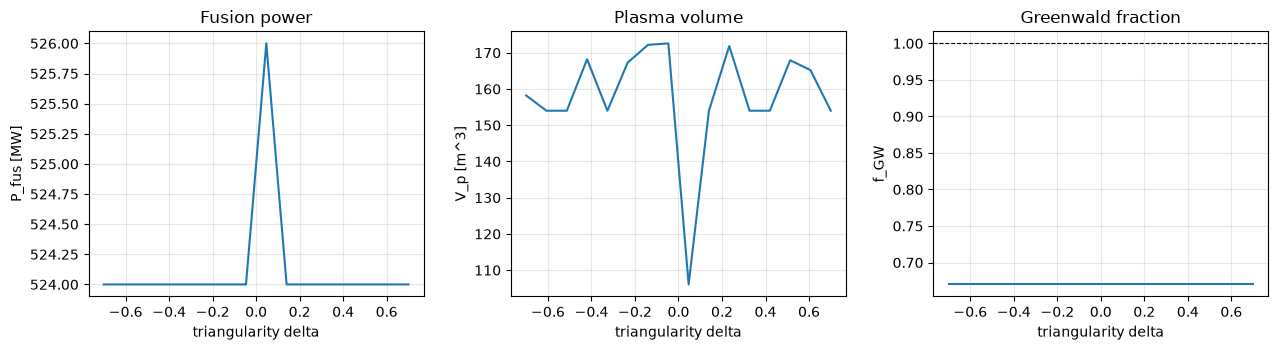

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
ax[0].plot(deltas, P_fus); ax[0].set_xlabel("triangularity delta"); ax[0].set_ylabel("P_fus [MW]"); ax[0].set_title("Fusion power")
ax[1].plot(deltas, V_p);   ax[1].set_xlabel("triangularity delta"); ax[1].set_ylabel("V_p [m^3]");   ax[1].set_title("Plasma volume")
ax[2].plot(deltas, f_GW);  ax[2].axhline(1.0, ls="--", c="k", lw=0.8)
ax[2].set_xlabel("triangularity delta"); ax[2].set_ylabel("f_GW"); ax[2].set_title("Greenwald fraction")
for a in ax: a.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Reconcile quality across the scan

ARC_V0 is a published, richly-specified scenario: it supplies more data than the
equation set can satisfy simultaneously, so `reconcile` returns the *nearest*
consistent point and reports which inputs it had to move beyond tolerance.  That
report -- and the per-value **role** tag -- is exactly the diagnostics
surface for reading a marginal solve, and it travels with every case.


In [5]:
# Which inputs are moved the most, aggregated across the scan?
from collections import Counter
moved = Counter()
for c in columns:
    for entry in (c.result.get("inputs_beyond_tolerance") or []):
        moved[entry["name"]] += 1
print("inputs beyond tolerance (count of cases):")
for name, k in moved.most_common(8):
    print(f"  {name:12s} {k:3d}/{len(columns)}")

# Origin of a few key outputs at the mid-scan point
# (fixed / movable = supplied data, computed = physics, assumed = nothing pins it)
mid = columns[len(columns)//2].result.get("compiler_report", {}).get("variable_roles", {})
print("\nroles @ mid-scan:", {k: mid.get(k) for k in ["P_fus", "V_p", "T_e", "delta"]})


inputs beyond tolerance (count of cases):
  tau_E         16/16
  T_i           16/16
  T_e_avg       16/16
  T_i_avg       16/16
  beta_T        16/16
  beta_N        16/16
  n_e           16/16
  n_i           16/16

roles @ mid-scan: {'P_fus': 'movable', 'V_p': 'movable', 'T_e': 'computed', 'delta': 'fixed'}


In [6]:
# Does delta actually DRIVE these quantities?  A certified point is not the same
# as an informative one, so check the response before reading the curves above:
# spread across the axis, and whether the step-to-step jitter is smaller than the
# overall trend (jitter > trend means solver root scatter, not delta dependence).
def response(name):
    a = col(name)
    if not np.all(np.isfinite(a)) or np.nanmax(np.abs(a)) == 0:
        return None
    spread = (a.max() - a.min()) / max(abs(np.median(a)), 1e-30)
    trend = abs(a[-1] - a[0])
    ratio = np.abs(np.diff(a)).max() / max(trend, 1e-30)
    if spread < 1e-4:
        verdict = "flat (does not respond)"
    elif ratio < 1.0:
        verdict = "SMOOTH trend in delta"
    else:
        verdict = "SCATTER (jitter > trend): solver root selection, not delta"
    return spread, ratio, verdict

print(f"{'variable':12s} {'spread':>9s} {'jitter/trend':>13s}  verdict")
for name in ("f_shaping", "A_p", "V_p", "P_fus", "f_GW", "q95", "beta_N", "tau_E", "n_e_avg"):
    r = response(name)
    print(f"{name:12s} {'  unavailable' if r is None else f'{r[0]:9.2%} {r[1]:13.2f}  {r[2]}'}")


variable        spread  jitter/trend  verdict
f_shaping       39.27%          0.62  SMOOTH trend in delta
A_p             15.66%          0.17  SMOOTH trend in delta
V_p             42.62%         15.81  SCATTER (jitter > trend): solver root selection, not delta
P_fus            0.38%    1288106.45  SCATTER (jitter > trend): solver root selection, not delta
f_GW             0.00%          0.00  flat (does not respond)
q95              0.19%          2.24  SCATTER (jitter > trend): solver root selection, not delta
beta_N          12.19%         30.85  SCATTER (jitter > trend): solver root selection, not delta
tau_E           49.71%          1.01  SCATTER (jitter > trend): solver root selection, not delta
n_e_avg         10.25%          6.39  SCATTER (jitter > trend): solver root selection, not delta


## Takeaways

* `fusdb.run_many(reactor, cases, mode=...)` runs an arbitrary parametric scan in
  parallel; each case is a full, faithful solve (works for `reconcile`,
  `optimize`, ...), not a popcon-grid special case.
* The `diagnostics` / `inputs_beyond_tolerance` / `variable_roles` fields let you
  read *how trustworthy* each swept point is, not just its numbers.
* **A green certificate is not the same as a meaningful sweep.** Here `delta`
  moves `f_shaping` and `A_p` smoothly, and nothing else: `P_fus` and `f_GW` are
  supplied inputs that stay pinned, and the `V_p` variation is root scatter (the
  cell above measures both). The cause is over-specification -- ARC_V0 supplies
  more data than the equation set can satisfy, so ~13 inputs sit beyond tolerance
  at every point and `delta` mostly redistributes which ones absorb the mismatch.
  A sweep axis only propagates into the operating point when that operating point
  has a free degree of freedom; on a fully determined design point it does not.
  This is worth checking for any new sweep before trusting its curves.
